#[1] Setup ambiente
## [1.1] Libraries

In [ ]:
import pandas as pd
import numpy as np
import os
import re
import ast
from google.colab import drive

from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
!pip3 install pyclustering
from pyclustering.cluster.kmedoids import kmedoids
#Risolvere problema dipendenze
#!pip install scikit-learn-extra
#from sklearn_extra.cluster import CLARA
from pyclustering.cluster.clarans import clarans
from sklearn.cluster import AgglomerativeClustering #AGNES
#DIANA : implementazione su github a https://github.com/div338/Divisive-Clustering-Analysis-Program-DIANA-
from sklearn.cluster import Birch
#Chameleon : implementazione su github a https://github.com/Moonpuck/chameleon_cluster
from sklearn.cluster import DBSCAN
from sklearn.cluster import OPTICS
#DENCLUE : implementazione su https://www.kaggle.com/code/hassanashfaq2001/denclue-clustering-algorithm
from pyclustering.cluster.clique import clique
#STING : nessuna implementazione trovata
from sklearn.cluster import HDBSCAN


from typing import Union
from sklearn.neighbors import BallTree
import time
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics import adjusted_rand_score as ARI
from sklearn.metrics.cluster import contingency_matrix as CM
from sklearn.metrics import homogeneity_completeness_v_measure as HCV


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 44.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=a5acdd098d7b422af441fee0228b5e62dd6811af85fce179ca38b34c79dba539
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering


##[1.2] Space setting


In [ ]:
drive.mount('/content/drive')
path_prefix=os.path.join('/content/drive','MyDrive','Data mining')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## [1.4] Utilities

In [ ]:
def profile(f):
    def f_timer(*args, **kwargs):
        start = time.time()
        result = f(*args, **kwargs)
        end = time.time()
        ms = (end - start) * 1000
        print(f"{f.__name__} ({ms:.3f} ms)")
        return result
    return f_timer


def csv_compress_IO(filename,IOtype):
  """
  Function used to open or save a csv file in a compress way (allows to push it to github repo)
  """
  if IOtype=="open":
    print("File opened successfully")
  elif IOtype=="save":
    print("File saved successfully")
  else:
    print("Wrong IOtype")


#[2] Pre-Processing
Here will be putted functions for:
- data pre-processing
- data integration

### 📘 YouTube Dataset Cleaning and Enrichment

In this notebook, we start with a CSV file containing information for each YouTube video in our dataset — including **title**, **description**, **tags**, and **categories**.

Our goal is to create a **cleaned and enriched version** of this dataset by applying a few smart preprocessing steps:

---

#### 🧹 Step 1 — Clean up the text fields
- Remove **Wikipedia links** (e.g., `https://en.wikipedia.org/...`) from the *categories* column.  
- Remove **generic URLs or hyperlinks** from the *description* field.

---

#### 🏷️ Step 2 — Enrich the tags
- Detect and extract **potential tags** that appear naturally inside the *description*.  
- Add those new tags to the existing list of tags for each video.

---

#### 💾 Output
The final result will be a **new CSV file** containing the same videos, but with:
- cleaner, more consistent text fields, and  
- an expanded and more accurate list of tags.

In [23]:
def linkParserList(original):
    '''
    Utility function used to extract pure categories from wikipedia link that embed those names
    :return: string like "['category1','category2',...,'categoryN']"
    '''
    topics = [] # Change topics to a list to collect categories
    lastword = ""

    # Return an empty list string if original is not a list
    if pd.isna(original):
      return "[]"

    for elem in original:
        if elem == '[' or elem == ']' or elem == "'" or elem == "," or elem == " ":
            if lastword: # Add the last word to the topics list before processing the special character
                topics.append(lastword)
                lastword = ""
            continue
        if elem == "/":
            lastword = ""
            continue
        lastword += elem

    if lastword: # Add the last word after the loop if it's not empty
      topics.append(lastword)

    return str(topics) # Return the string representation of the list

def videoDocumentExtraction(csvName,sanitizationlvl=0):
    '''
    Take the dataset containing information on youtube videos,
    generate documents for each videos that contain the knowledge
    and collect them in a dataframe with compact information

    :param sanitizationlvl: specify the level of sanitization in the knoledge extracted from videos (e.g remove tags, link...). Default doesn't sanitize.
    :return: dataframe [channelId,videoId,content]
    '''
    description_clear = ""
    description_tags = []
    video_path=os.path.join(path_prefix,"Results",csvName)
    videosDf = pd.read_csv(video_path)
    documentList=[]
    taggerList=[]
    topicsList=[]
    for index, row in videosDf.iterrows():
        if pd.isna(row["description"]):
            description_clear=""
        else:
            # remove the links from the description
            description_clear = re.sub(r"http\S+", "", row["description"])
            # finds the tag in the description
            description_tags = re.findall(r"#\w+", description_clear)
            description_tags = [t[1:].lower() for t in description_tags]
            # remove all the tags in the description and remove double space
            description_clear = re.sub(r"#\w+", "", description_clear)
            description_clear = re.sub(r"\s+", " ", description_clear).strip()

        # this will be the content on which sbert works
        document = row["title"] + '\n' + description_clear
        documentList.append(document)

        # now we have to create a list of tagger
        topics_str = linkParserList(row["topicCategories"]) # Get the string representation
        topics = [t.lower() for t in ast.literal_eval(topics_str)] # Evaluate the string
        tags = [t.lower() for t in ast.literal_eval(row["tags"])]
        topicsList.append(topics)

        if not description_clear:
            for description_tag in description_tags:
                if description_tag not in tags:
                    tags.append(description_tag)
        taggerList.append(tags)

    documentsDf = videosDf.copy()
    documentsDf = documentsDf[["channelId", "videoId"]]
    documentsDf["content"]=documentList
    documentsDf["tags"]=taggerList
    documentsDf["topics"]=topicsList
    documentsDf.columns=["channelId","videoId","content", "tags", "topics"]
    return documentsDf

doc=videoDocumentExtraction("videos_youtuber_us.csv")
doc.to_csv(os.path.join(path_prefix,"Results","videos_documents.csv"),index=False)

In [24]:
print(doc)

                      channelId      videoId  \
0      UCf1Q757aKSmywQDQhiTtGFA  5IewOvaQtTg   
1      UCf1Q757aKSmywQDQhiTtGFA  E9d-pSU0HLs   
2      UCf1Q757aKSmywQDQhiTtGFA  pcnzj2RNbo0   
3      UCf1Q757aKSmywQDQhiTtGFA  TM6CInJx-XU   
4      UCf1Q757aKSmywQDQhiTtGFA  Ox90jpnHhIk   
...                         ...          ...   
76304  UCLF-hR7gDrpUnEm3NdKAb6g  FDc1MZz1W4c   
76305  UCLF-hR7gDrpUnEm3NdKAb6g  Z74nDdBZQbk   
76306  UCLF-hR7gDrpUnEm3NdKAb6g  2rPI3jbbg1I   
76307  UCLF-hR7gDrpUnEm3NdKAb6g  S41md84wO0E   
76308  UCLF-hR7gDrpUnEm3NdKAb6g  9uYLaumU0Vg   

                                                 content  \
0      Yungeen Ace - Im Sorry (Official Video)\nListe...   
1      Yungeen Ace -  Under The Street Lights (Offici...   
2      Yungeen Ace - Sacrifice Erverybody (Official A...   
3      Yungeen Ace - Deep Thoughts (Official Audio)\n...   
4      Yungeen Ace - Oh Way Oh No (Official Audio)\nL...   
...                                                  ...   
763

In [25]:
# Count the number of empty lists in the 'topics' column
empty_topics_count = doc['topics'].apply(lambda x: len(x) == 0).sum()
total_entries = len(doc)

# Calculate the percentage of empty topic lists
percentage_empty_topics = (empty_topics_count / total_entries) * 100

print(f"Total number of entries: {total_entries}")
print(f"Number of entries with empty topic lists: {empty_topics_count}")
print(f"Percentage of entries with empty topic lists: {percentage_empty_topics:.2f}%")

Total number of entries: 76309
Number of entries with empty topic lists: 2370
Percentage of entries with empty topic lists: 3.11%


In [27]:
# Display basic statistics for the DataFrame
display(doc.info())
display(doc.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76309 entries, 0 to 76308
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   channelId  76309 non-null  object
 1   videoId    76309 non-null  object
 2   content    76309 non-null  object
 3   tags       76309 non-null  object
 4   topics     76309 non-null  object
dtypes: object(5)
memory usage: 2.9+ MB


None

,channelId,videoId,content,tags,topics
count,76309,76309,76309,76309,76309
unique,1234,76040,72560,27824,797
top,UCBnxEdpoZwstJqC1yZpOjRA,INu45nbqQug,🔴Live stream🔴\n,[],"[entertainment, film, television_program]"
freq,6095,3,710,13885,7760


#[3] Data mining
Here will be putted functions for information discovery of the main pipeline to obtain the final model


In [ ]:
@profile
def hopkins(data_frame: Union[np.ndarray, pd.DataFrame], sampling_size: int) -> float:
    """Assess the clusterability of a dataset. A score between 0 and 1, a score around 0.5 express
    no clusterability and a score tending to 0 express a high cluster tendency.

    Examples
    --------
    >>> from sklearn import datasets
    >>> from pyclustertend import hopkins
    >>> X = datasets.load_iris().data
    >>> hopkins(X,150)
    0.16
    """

    if type(data_frame) == np.ndarray:
        data_frame = pd.DataFrame(data_frame)

    data_frame_sample = sample_observation_from_dataset(data_frame, sampling_size)

    sample_distances_to_nearest_neighbours = get_distance_sample_to_nearest_neighbours(
        data_frame, data_frame_sample
    )

    uniformly_selected_observations_df = simulate_df_with_same_variation(
        data_frame, sampling_size
    )

    df_distances_to_nearest_neighbours = get_nearest_sample(
        data_frame, uniformly_selected_observations_df
    )

    x = sum(sample_distances_to_nearest_neighbours)
    y = sum(df_distances_to_nearest_neighbours)

    if x + y == 0:
        raise Exception("The denominator of the hopkins statistics is null")

    return y / (x + y)[0]


def get_nearest_sample(df: pd.DataFrame, uniformly_selected_observations: pd.DataFrame):
    tree = BallTree(df, leaf_size=2)
    dist, _ = tree.query(uniformly_selected_observations, k=1)
    uniformly_df_distances_to_nearest_neighbours = dist
    return uniformly_df_distances_to_nearest_neighbours


def simulate_df_with_same_variation(
    df: pd.DataFrame, sampling_size: int
) -> pd.DataFrame:
    max_data_frame = df.max()
    min_data_frame = df.min()
    uniformly_selected_values_0 = np.random.uniform(
        min_data_frame.iloc[0], max_data_frame.iloc[0], sampling_size
    )
    uniformly_selected_values_1 = np.random.uniform(
        min_data_frame.iloc[1], max_data_frame.iloc[1], sampling_size
    )
    uniformly_selected_observations = np.column_stack(
        (uniformly_selected_values_0, uniformly_selected_values_1)
    )
    if len(max_data_frame) >= 2:
        for i in range(2, len(max_data_frame)):
            uniformly_selected_values_i = np.random.uniform(
                min_data_frame.iloc[i], max_data_frame.iloc[i], sampling_size
            )
            to_stack = (uniformly_selected_observations, uniformly_selected_values_i)
            uniformly_selected_observations = np.column_stack(to_stack)
    uniformly_selected_observations_df = pd.DataFrame(uniformly_selected_observations)
    return uniformly_selected_observations_df

def get_distance_sample_to_nearest_neighbours(df: pd.DataFrame, data_frame_sample):
    tree = BallTree(df, leaf_size=2)
    dist, _ = tree.query(data_frame_sample, k=2)
    data_frame_sample_distances_to_nearest_neighbours = dist[:, 1]
    return data_frame_sample_distances_to_nearest_neighbours


def sample_observation_from_dataset(df, sampling_size: int):
    if sampling_size > df.shape[0]:
        raise Exception("The number of sample of sample is bigger than the shape of D")
    data_frame_sample = df.sample(n=sampling_size)
    return data_frame_sample


def silhoutte(X,model):
    silhouette_list = []
    inertia_list = []
    f, axes = plt.subplots(2, 4, figsize=(20, 10))
    for n_clusters in range(2, 10):
        #kmeans = KMeans(n_clusters=n_clusters, random_state=10, n_init='auto')
        #y_pred = kmeans.fit_predict(X)
        model_hyp=model(n_clusters=n_clusters, random_state=10, n_init='auto')
        y_pred=model_hyp.fit_predict(X)

        """
            models=[KMeans(),
            kmedoids(),
            clarans(),
            AgglomerativeClustering(),
            Birch(),
            DBSCAN(),
            OPTICS(),
            clique(),
            HDBSCAN()
            ]

        """

        # evaluate silhouette score
        silhouette_avg = silhouette_score(X, y_pred)
        silhouette_list.append(silhouette_avg)

        # evaluate inertia
        inertia = model_hyp.inertia_
        inertia_list.append(inertia)

        # display clustered samples
        axes[(n_clusters - 2) // 4][(n_clusters - 2) % 4].scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_pred, alpha=0.5)
        axes[(n_clusters - 2) // 4][(n_clusters - 2) % 4].axis('equal')
        axes[(n_clusters - 2) // 4][(n_clusters - 2) % 4].set_xlabel('Feature 1')
        axes[(n_clusters - 2) // 4][(n_clusters - 2) % 4].set_ylabel('Feature 2')
        axes[(n_clusters - 2) // 4][(n_clusters - 2) % 4].set_title(
            f'k = {n_clusters} - Avg. Silhouette = {silhouette_avg:.2} - n_iter = {model_hyp.n_iter_}')

        # display clusters centroids
        centers = model_hyp.cluster_centers_
        axes[(n_clusters - 2) // 4][(n_clusters - 2) % 4].scatter(centers[:, 0], centers[:, 1], marker='x', c='r')

    plt.tight_layout()

    # plot silhouette and inertia trends w.r.t the number of clusters
    fig, ax1 = plt.subplots()
    ax1.set_xlabel('k')
    ax1.set_ylabel('avg-silhouette', color='black')
    ax1.plot(range(2, 10), silhouette_list, '--ok')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.grid(axis='y')

    ax2 = ax1.twinx()
    ax2.set_ylabel('loss', color='red')
    ax2.plot(range(2, 10), inertia_list, '--or', alpha=0.2)
    ax2.tick_params(axis='y', labelcolor='red')

    plt.tight_layout()  # otherwise the right y-label is slightly clipped

    plt.show()

def centroidImpact(X,n=4):
    avg_sil_random = [silhouette_score(X, KMeans(n_clusters=n, init='random', random_state=i, n_init=1).fit_predict(X)) for i in range(100)]

    avg_sil_plusplus = [silhouette_score(X,KMeans(n_clusters=n, init='k-means++', random_state=i, n_init=1).fit_predict(X)) for i in range(100)]

    df = pd.DataFrame({'random': avg_sil_random, 'km++': avg_sil_plusplus})
    df.boxplot(ylabel='Avg. Silhouette')
    plt.show()

    axes = df.hist(sharey=True)
    for ax in axes.flatten():
        ax.set_xlabel('Avg. Silhouette')


def qualityMetrics(X,y_groundTruth,y,n=4):
    print(f'kmeans with n_cluster = {n} --> ARI = {ARI(y, y_groundTruth): .03}')
    CM(y, y_groundTruth)
    homogeneity, completeness, v_measure = HCV(y, y_groundTruth)
    print(f'homogeneity: {homogeneity: .3}')
    print(f'completeness: {completeness: .3}')
    print(f'v_measure: {v_measure: .3}')

In [ ]:

# Load a pre-trained SentenceTransformer model
colList = [f"c{i}" for i in range(1, 1025)]
@profile
def sbertCalc(fileName="videos_documents.csv"):
    print("SBERT step")
    model = SentenceTransformer("mixedbread-ai/mxbai-embed-large-v1")
    videosDf=pd.read_csv(os.path.join(path_prefix,"Results",fileName))
    videosDf=videosDf.head(500)
    videosSbert=videosDf.copy()
    embeddings = model.encode_document(list(videosDf['content']))
    print(embeddings.shape)
    data=pd.DataFrame(embeddings,columns=colList)
    videosSbert=pd.concat([videosSbert,data],axis=1)
    return videosSbert

sbertDF=sbertCalc()
sbertDF.to_csv(os.path.join(path_prefix,"Results","videos_sbert.csv"),index=False)

SBERT step


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

(500, 1024)
sbertCalc (42787.491 ms)


CLUSTERING step (Hopkins)
hopkins (1045.727 ms)
Hopkins stat:  [0.78959385]


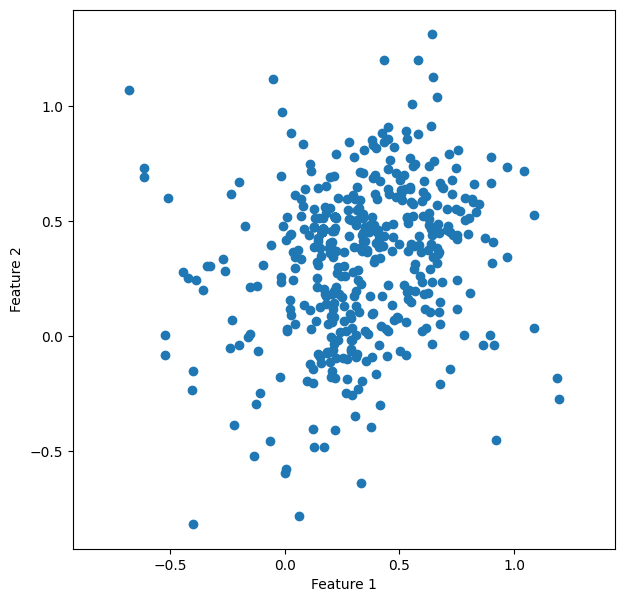

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 

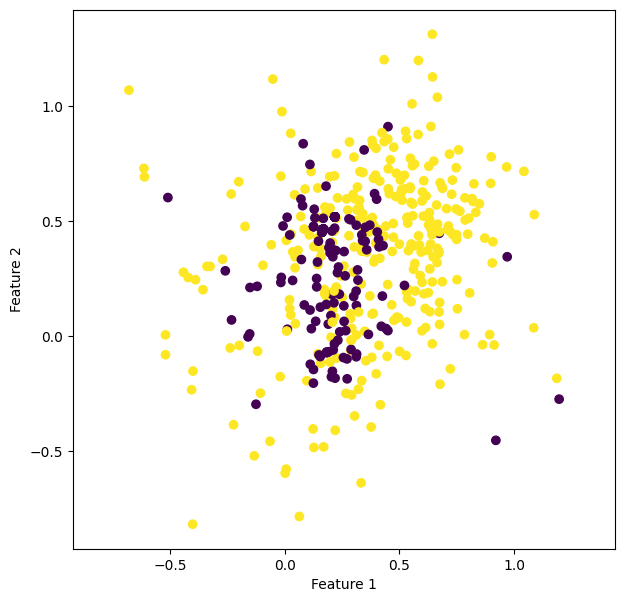

clustering (5592.404 ms)


In [ ]:
@profile
def clustering(fileName="videos_sbert.csv"):
    df=pd.read_csv(os.path.join(path_prefix,"Results",fileName))
    print("CLUSTERING step (Hopkins)")
    X=df.iloc[:,4:]

    #Compute Hopkins statistic
    print(f"Hopkins stat: ",hopkins(X,df.shape[0]))

    #Little visualization
    plt.figure(figsize=(7, 7))
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1])
    plt.axis('equal') # force equal axes aspect ratio
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

    #model_hyp=model(n_clusters=n_clusters, random_state=10, n_init='auto')
    #y_pred=model_hyp.fit_predict(X)
    kmeans = KMeans(n_clusters=2, random_state=10, n_init='auto')
    y_pred = kmeans.fit_predict(X)
    print(y_pred)

    model=kmedoids(X.values,[1,2])
    model.process();
    clusters = model.get_clusters()
    n_samples = max(max(c) for c in clusters) + 1
    y_pred = np.empty(n_samples, dtype=int)
    for cluster_id, indices in enumerate(clusters):
        y_pred[indices] = cluster_id
    print(y_pred)



    plt.figure(figsize=(7, 7))
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1],c=y_pred)
    plt.axis('equal') # force equal axes aspect ratio
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

    """
    models=[KMeans] # Pass the class, not an instance

    for model in models:
        silhoutte(X,model)

    models=[KMeans(),
            kmedoids(),
            clarans(),
            AgglomerativeClustering(),
            Birch(),
            DBSCAN(),
            OPTICS(),
            clique(),
            HDBSCAN()
            ]

    #finding number of clustering k
    silhoutte(X)
    n=4

    #clustering
    kmeans = KMeans(n_clusters=n, random_state=10, n_init='auto')
    y = kmeans.fit_predict(X)

    #Quality of clustering
    centroidImpact(X,n)
        #with ground truth
    #qualityMetrics(X,y_groundTruth,y,n)
    """

clustering()